In [4]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [5]:
df  = pd.read_csv('../data/train.csv')

In [6]:
df.head(6)

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1
5,5,24,admin.,single,secondary,no,1882,yes,no,cellular,20,apr,1010,3,-1,0,unknown,0


In [7]:
df.columns

Index(['id', 'age', 'job', 'marital', 'education', 'default', 'balance',
       'housing', 'loan', 'contact', 'day', 'month', 'duration', 'campaign',
       'pdays', 'previous', 'poutcome', 'y'],
      dtype='object')

In [8]:
df.shape

(750000, 18)

In [9]:
# 1. Missing values check

In [10]:
df.isnull().sum() # No missing data. 

id           0
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [11]:
# 2. duplicate check:
df.duplicated().sum() ## No duplicate. 

0

In [12]:
# 3. consistency check.

In [13]:
numeric_cols = df.select_dtypes(include = ['float', 'int']).columns
categorical_cols = df.select_dtypes(exclude = ['int64','float64']).columns

### categorical Data

In [14]:
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [15]:
df['job'].value_counts()

job
management       175541
blue-collar      170498
technician       138107
admin.            81492
services          64209
retired           35185
self-employed     19020
entrepreneur      17718
unemployed        17634
housemaid         15912
student           11767
unknown            2917
Name: count, dtype: int64

In [16]:
# percentage distribution of job category. 
df['job'].value_counts()/len(df) * 100

job
management       23.405467
blue-collar      22.733067
technician       18.414267
admin.           10.865600
services          8.561200
retired           4.691333
self-employed     2.536000
entrepreneur      2.362400
unemployed        2.351200
housemaid         2.121600
student           1.568933
unknown           0.388933
Name: count, dtype: float64

In [17]:
df['marital'].value_counts()/ len(df)*100

marital
married     64.101200
single      25.977867
divorced     9.920933
Name: count, dtype: float64

In [18]:
df['education'].value_counts() * 100 / len(df)

education
secondary    53.557733
tertiary     30.334400
primary      13.268000
unknown       2.839867
Name: count, dtype: float64

In [19]:
df['default'].value_counts() * 100 / len(df)
# Only 1.7 % did default in the previous credit transactions. 

default
no     98.2868
yes     1.7132
Name: count, dtype: float64

In [20]:
df['housing'].value_counts()*100 / len(df)
# having housing loan - yes/no

housing
yes    54.8384
no     45.1616
Name: count, dtype: float64

In [21]:
df['loan'].value_counts()*100 / len(df)
# having personal loan: - yes/No

loan
no     86.003067
yes    13.996933
Name: count, dtype: float64

In [22]:
# housing loan v/s personal loan. 
pd.crosstab(df['housing'], df['loan'])

loan,no,yes
housing,,
no,299595,39117
yes,345428,65860


In [23]:
df['contact'].value_counts()*100/ len(df)

contact
cellular     64.887333
unknown      30.883600
telephone     4.229067
Name: count, dtype: float64

### Numerical Data

In [24]:
# 4. Outlier & Noise check. 

In [25]:
# Age
df['age'].min(), df.age.max(), df.age.mean(), df.age.median()

(18, 95, 40.92639466666667, 39.0)

In [26]:
df['age'].skew() # roughly symmetric. 

0.5861373244498731

In [27]:
## IQR check . 
q1 = df.age.quantile(0.25)
q3 = df.age.quantile(0.75)
iqr = q3 - q1  
outlier = df[(df['age'] > (q3+1.5 * iqr))  | (df['age'] < (q1 - 1.5*iqr))]
len(outlier)/len(df)*100

0.6537333333333334

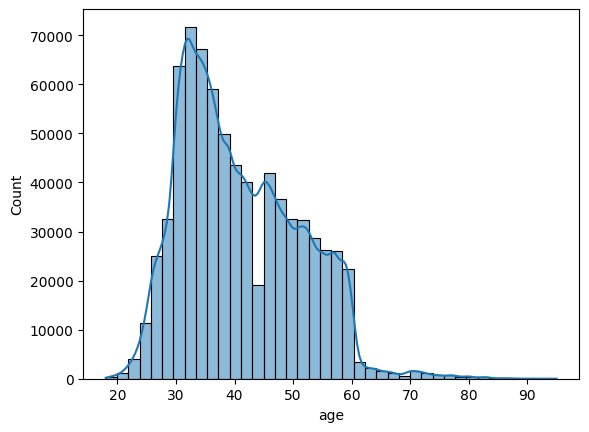

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df['age'], bins=40, kde= True)
plt.show()

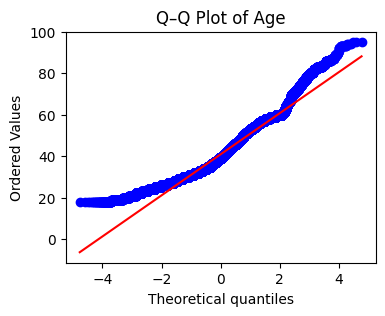

In [29]:
import matplotlib.pyplot as plt
import scipy.stats as stats

# Q–Q plot for age column
plt.figure(figsize=(4,3))
stats.probplot(df["age"], dist="norm", plot=plt)
plt.title("Q–Q Plot of Age")
plt.show()

In [30]:
# Balance
df.balance.min(), df.balance.max(), df.balance.mean(), df.balance.median()

(-8019, 99717, 1204.0673973333332, 634.0)

<Axes: xlabel='balance', ylabel='Count'>

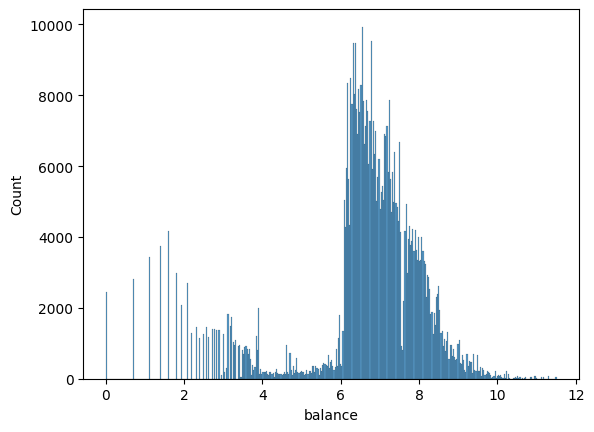

In [31]:
import math
xx = np.log(df.balance)
sns.histplot(xx)

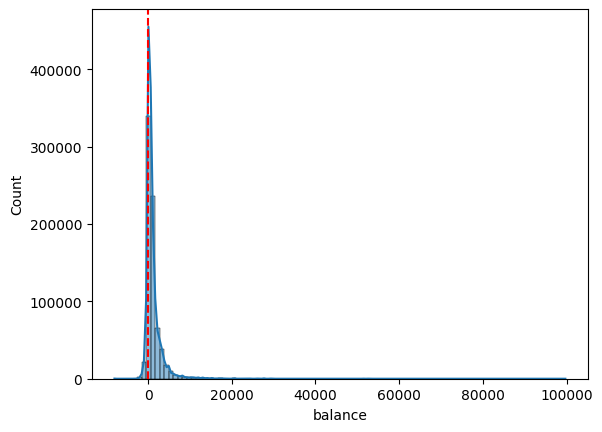

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['balance'], kde=True, bins=100)
plt.axvline(0, color='red', linestyle='--')  # mark zero line
plt.show()

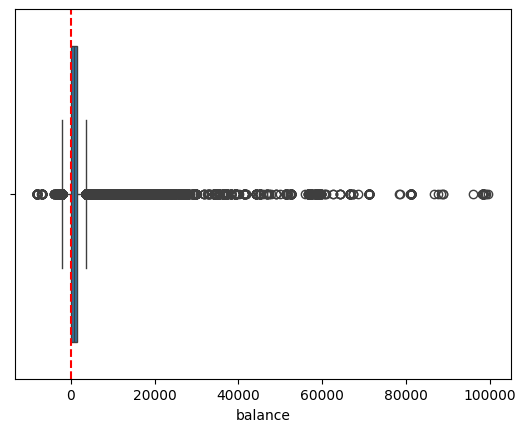

In [33]:
sns.boxplot(x=df['balance'])
plt.axvline(0, color='red', linestyle='--')
plt.show()

In [34]:
df.balance.value_counts() / len(df) * 100 
# ! 12 % customers have 0 Balance in account. 

balance
 0        12.421200
 5         0.556533
 4         0.498800
-1         0.476400
 3         0.457200
            ...    
 8943      0.000133
 52496     0.000133
 10821     0.000133
 52357     0.000133
 8218      0.000133
Name: count, Length: 8217, dtype: float64

<Axes: xlabel='balance', ylabel='Density'>

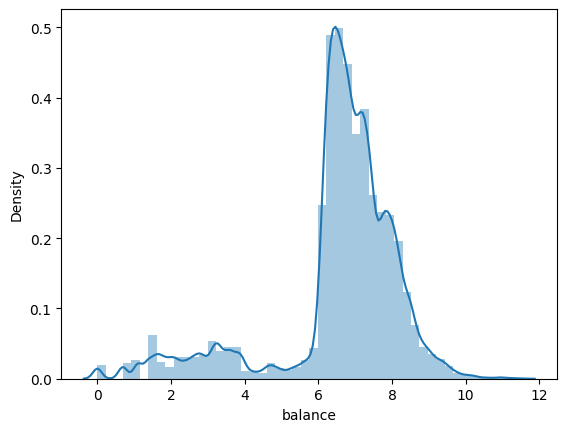

In [35]:
# +ve balance
sns.distplot(np.log(df[df.balance > 0].balance))

<Axes: xlabel='balance', ylabel='Density'>

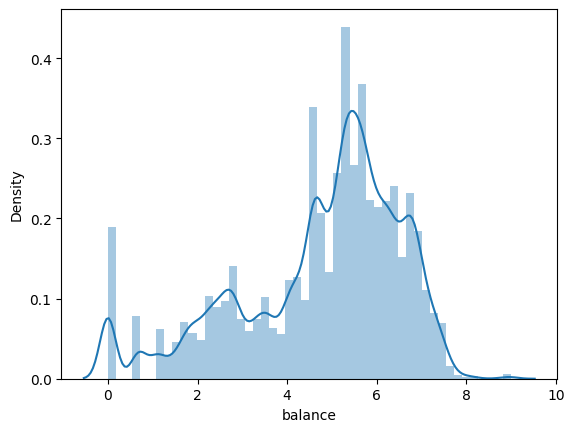

In [36]:
# -ve balance. 
sns.distplot(np.log(-1*df[df.balance < 0].balance))

In [37]:
# Balance is mix of -ve, +ve, 0 data. 

In [38]:
## Day of the Month:

<Axes: xlabel='day', ylabel='Density'>

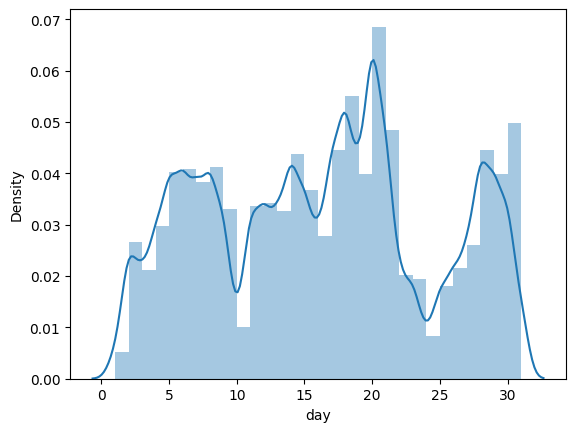

In [39]:
sns.distplot(df.day, bins= 30)

In [40]:
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

In [41]:
df.month.value_counts() / len(df)*100

month
may    30.454800
aug    17.181200
jul    14.752933
jun    12.489333
nov     8.808267
apr     5.509200
feb     5.014800
jan     2.524933
oct     1.227200
sep     0.987867
mar     0.773600
dec     0.275867
Name: count, dtype: float64

In [42]:
## we can derive inference from this only when set the current date. 

In [43]:
df.campaign.value_counts()

campaign
1     304481
2     209834
3      88683
4      60974
5      25648
6      19694
7      10360
8       7777
9       3993
10      3511
11      2576
12      2027
13      1720
14      1231
15      1099
16      1018
17       902
18       678
19       556
20       530
21       414
22       272
25       262
23       236
24       226
29       182
28       176
31       153
26       134
30       103
27       100
32        88
33        64
35        55
34        48
36        31
37        30
38        30
41        19
43        16
40        13
50        11
44        10
46         8
39         8
51         7
45         4
42         3
48         2
55         1
63         1
58         1
Name: count, dtype: int64

In [44]:
df.pdays.value_counts()/len(df)*100
# ~90% people are contacted for the first time. 

pdays
-1      89.657867
 182     0.335333
 92      0.303333
 183     0.276533
 181     0.226400
          ...    
 759     0.000133
 529     0.000133
 794     0.000133
 617     0.000133
 376     0.000133
Name: count, Length: 596, dtype: float64

In [45]:
df.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [101]:
df.poutcome.value_counts()

poutcome
unknown    672450
failure     45115
success     17691
other       14744
Name: count, dtype: int64

In [46]:
x =df[(df.pdays == -1 ) & (df.previous != 0)]
len(x)
# ! conflicting case:- although the client was not contacted in past through any compaign, but still the no of previous contacts is Non-zero


17

In [47]:
# Outcome of the previous marketing campaign.
df.poutcome.value_counts()/len(df)*100

poutcome
unknown    89.660000
failure     6.015333
success     2.358800
other       1.965867
Name: count, dtype: float64

In [48]:
# Target variable.
df.y.value_counts()/len(df)*100
# ? Imbalance Dataset

y
0    87.934933
1    12.065067
Name: count, dtype: float64

## Bivariate Analysis

Let's examine how each of the categorical and numerical features relate to the target outcome. 

### Categorical v/s Target (y)
- Cross-tabulation: Frequency table for each feature v/s target
- Box-plot : Subscription rates(y) (Yes/No) for each category
- Chi-square Tests:- Statistical significance. to conclude that things are occuring by random or is there any meaning to that. 

- categorical features:- `job`, `marital`, `education`, `default`, `housing`, `loan`,  `contact`, `month`,  `campaign`, `poutcome`

```['job']```

In [103]:
categorical_features = " `job`, `marital`, `education`, `default`, `housing`, `loan`,  `contact`, `month`,  `campaign`, `poutcome`"

In [52]:
# cross-tab: contingency table for 'job' vs 'y'
import pandas as pd
cross_tab = pd.crosstab(df.job, df.y, margins=True, normalize='index')
print(cross_tab)

y                     0         1
job                              
admin.         0.883547  0.116453
blue-collar    0.932562  0.067438
entrepreneur   0.918614  0.081386
housemaid      0.915347  0.084653
management     0.849608  0.150392
retired        0.753759  0.246241
self-employed  0.870557  0.129443
services       0.917286  0.082714
student        0.659216  0.340784
technician     0.881679  0.118321
unemployed     0.820177  0.179823
unknown        0.879328  0.120672
All            0.879349  0.120651


In [79]:
# proportion of yes for each job type.

In [ ]:
df.groupby('job').agg({
    'y': ['mean']
}).sort_values(('y', 'mean'), ascending=False) * 100

# Student having the maximum conversion rate
# student > retired > unemployed > self-employed, .. > technician > admin > housemaid >  > ... blue-collar

,y
,mean
job,
student,34.078355
retired,24.624130
unemployed,17.982307
management,15.039222
self-employed,12.944269
unknown,12.067192
technician,11.832130
admin.,11.645315


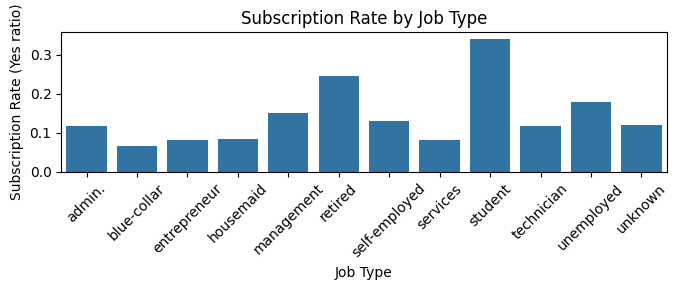

In [93]:
# Visualization (Bar plot)
import seaborn as sns
import matplotlib.pyplot as plt
yes_rate_by_job = df.groupby('job')['y'].value_counts(normalize=True).unstack()[1]
plt.figure(figsize=(7,3))
sns.barplot(x=yes_rate_by_job.index, y=yes_rate_by_job.values)
plt.title('Subscription Rate by Job Type')
plt.ylabel('Subscription Rate (Yes ratio)')
plt.xlabel('Job Type')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

```
1. Students, retirees, unemployed are more likely to subscribe compared to other groups
2. Possibly these groups find the term deposit attractive (may be for stability or saving growth).

```


#### statistical test:-
- subscription rate is occuring by chance ? ?
- `Ho`: Subscription rate is independent of job category
- `H1`: Job influence the probability of 'yes' (1)

In [94]:
from scipy.stats import chi2_contingency
# contigency table
contigency = pd.crosstab(df['job'], df['y'])
# chi-square test
chi2, p, dof, expected = chi2_contingency(contigency)

print("chi-square statistics: ", chi2)
print("p-Value: ", p)

chi-square statistics:  18558.875547641317
p-Value:  0.0


`Job-type is significant feature determining the subscription rate`

`marital`- status

In [106]:
df.groupby('marital').agg({
    'y': ['mean']
}) * 100

,y
,mean
marital,
divorced,11.157552
married,10.187225
single,17.045280


### Numerical vs Target (y)
- Boxplots or violin plots: Compare distributions of numerical variables (age, balance, duration, campaign, pdays, previous) by subscription outcome.

- Group means/medians: Calculate the average age, balance, or duration for clients who subscribed vs. did not.

- T-tests or Mann-Whitney U tests: Statistically compare means/medians between groups.